# Study 784 — Analyst-Cluster — for the quants 🔬

The full battery: one-sample *t* per window, a random-window placebo, a leave-one-out jackknife, the costed net leg, and a seeded synthetic positive control. Everything offline once cached; fingerprint `31db942be633`.

**LABELLED PROXY:** cluster week = NVDA's real earnings week (post-print PT-hike wave). Confound to keep in mind throughout: this window also carries PEAD.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from analyst_cluster import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching NVDA + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} clusters resolved")


panel loaded; 39 of 39 clusters resolved


## 1. One-sample *t* across independent clusters

Each cluster is one independent event, so the unit is a one-sample *t* of the per-cluster abnormal return — **not** a daily panel (which would fake precision). The fade (`post_*`) is the tested short; a negative mean would support it.

In [2]:
for label, col in [('2wk run-up','pre_s'),('1mo run-up','pre_l'),('2wk fade','post_s'),('1mo fade','post_l')]:
    s = st.one_sample_t(inc[col].values)
    print(f'{label:<12s} n={s["n"]}  mean={s["mean"]*100:+.3f}%  sd={s["sd"]*100:.2f}%  t={s["t"]:+.3f}')

2wk run-up   n=39  mean=+2.292%  sd=6.12%  t=+2.339
1mo run-up   n=39  mean=+5.274%  sd=9.25%  t=+3.562
2wk fade     n=39  mean=+4.756%  sd=13.97%  t=+2.126
1mo fade     n=39  mean=+5.060%  sd=16.09%  t=+1.964


## 2. Random-window placebo — is the post-cluster move inside NVDA's luck cloud?

For each event we redraw a random, non-cluster 2-week window on NVDA vs SPY and recompute the abnormal return; 20 seeds × 200 draws. The **placebo mean is already ~+2%** — that's the single-name selection baseline. The fade window sits in the far *right* tail of that null (left-tail p ≈ 0.985): abnormally *positive*, the opposite of a fade.

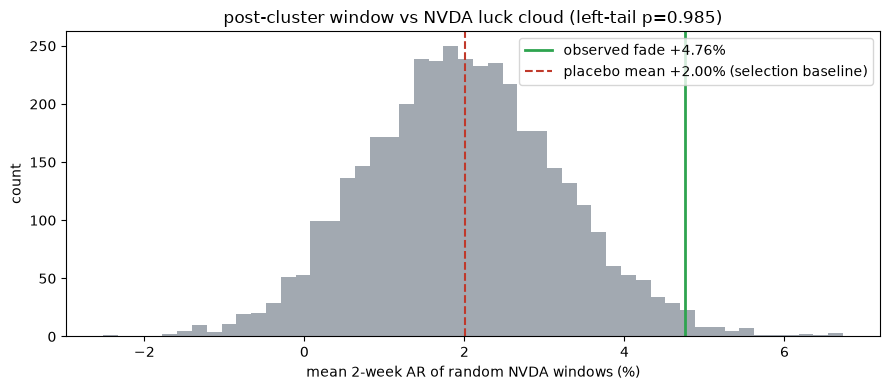

placebo: {'obs': 0.0476, 'placebo_mean': 0.02, 'placebo_sd': 0.0124, 'p_value': 0.985, 'n_draws': 4000}


In [3]:
pl = st.placebo_pvalue(ev, prices, 'post_s', k=10, tail='left')
aapl, spy = prices[dt.INSTRUMENT], prices[dt.BENCHMARK]
common = aapl.index.intersection(spy.index).sort_values()
rng = np.random.default_rng(999); draws = []
for _ in range(4000):
    vals = []
    for _e in range(int(inc.shape[0])):
        p = int(rng.integers(0, len(common)-11))
        vals.append(float(aapl.loc[common[p+10]]/aapl.loc[common[p]] - spy.loc[common[p+10]]/spy.loc[common[p]]))
    draws.append(np.mean(vals))
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(np.array(draws)*100, bins=50, color='#8b949e', alpha=0.8)
ax.axvline(pl['obs']*100, color='#2ea44f', lw=2, label=f"observed fade {pl['obs']*100:+.2f}%")
ax.axvline(pl['placebo_mean']*100, color='#c0392b', lw=1.5, ls='--', label=f"placebo mean {pl['placebo_mean']*100:+.2f}% (selection baseline)")
ax.set_xlabel('mean 2-week AR of random NVDA windows (%)'); ax.set_ylabel('count')
ax.set_title(f"post-cluster window vs NVDA luck cloud (left-tail p={pl['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('placebo:', {k: round(v,4) if isinstance(v,float) else v for k,v in pl.items()})

## 3. Jackknife — is the upward drift one AI-boom quarter, or broad?

In [4]:
x = inc['post_s'].values
jk = [st.one_sample_t(np.delete(x, i))['t'] for i in range(len(x))]
print(f'full-sample fade t = {st.one_sample_t(x)["t"]:+.3f}')
print(f'jackknife t range [{min(jk):+.3f}, {max(jk):+.3f}] over {len(x)} leave-one-out draws')

full-sample fade t = +2.126
jackknife t range [+1.838, +2.464] over 39 leave-one-out draws


## 4. Tradability — net of costs

Calendar-known entry, so the signal window and the tradable window coincide. The *fade* (the tested trade) is a **loser** at every cost level — you'd be shorting a +4.7%/2wk window on one of the priciest names to borrow. The mirror long-the-drift survives costs but is plain PEAD on a single hand-picked winner.

In [5]:
ev10 = st.build_event_table(prices, cost_bps=10.0); inc10 = ev10[ev10['included']]
for base, label in [('post_s','2wk fade'),('pre_s','2wk run-up')]:
    g = st.one_sample_t(inc[base].values); n5 = st.one_sample_t(inc[base+'_net'].values); n10 = st.one_sample_t(inc10[base+'_net'].values)
    print(f'{label:<12s} gross {g["mean"]*100:+.3f}% (t={g["t"]:+.2f})  net@5 {n5["mean"]*100:+.3f}% (t={n5["t"]:+.2f})  net@10 {n10["mean"]*100:+.3f}% (t={n10["t"]:+.2f})')

2wk fade     gross +4.756% (t=+2.13)  net@5 +4.656% (t=+2.08)  net@10 +4.556% (t=+2.04)
2wk run-up   gross +2.292% (t=+2.34)  net@5 +2.192% (t=+2.24)  net@10 +2.092% (t=+2.13)


## 5. Synthetic positive control — the detector works, and the null is honest

The one-sample-*t* detector must stay quiet on a planted-null world and recover a planted pre-cluster bump. At n = 39 the small-sample false-positive rate is near-nominal (|*t*| ≥ 2 on ~3/20 null seeds), and a planted bump is recovered monotonically.

null: mean t=-0.02 sd=1.30  |t|>=2 in 3/20 seeds
planted +1%: mean AR +0.777%  t=+1.00
planted +2%: mean AR +1.777%  t=+2.30


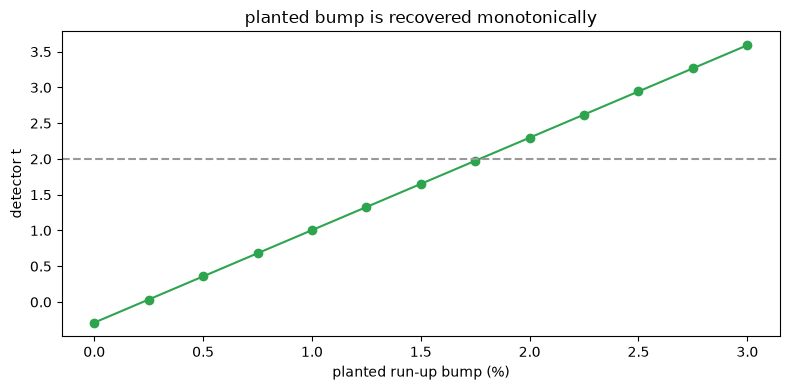

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=803+s, k=10)['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.01, 0.02):
    r = st.synthetic_detect(bump=b, seed=803, k=10)
    print(f'planted +{b*100:.0f}%: mean AR {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.03, 13)
ts = [st.synthetic_detect(bump=b, seed=803, k=10)['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#2ea44f')
ax.axhline(2, color='0.6', ls='--'); ax.set_xlabel('planted run-up bump (%)'); ax.set_ylabel('detector t')
ax.set_title('planted bump is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** The tested fade is not real — it is confidently *wrong-signed*: NVDA drifts **up** +4.76%/2wk (*t* = +2.13, placebo far-right p ≈ 0.985, jackknife [+1.84, +2.46]) after the cluster. What's present is an *upward* post-earnings drift, but on a single hand-picked mega-winner whose random windows already beat SPY by +2% — neither the claim nor generalizable. **Tradability: Mirage.** The fade loses ~+4.7%/event before borrow; the mirror long is one-name PEAD on a +2% selection baseline, no capacity or cross-sectional edge.